In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("stock_analysis.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date")

# Calculate daily return
df["Daily_Return"] = df["Close"].pct_change() * 100

# Calculate moving averages
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

df

,Date,Open,High,Low,Close,Volume,Daily_Return,MA_20,MA_50
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,-0.150000,NaN,NaN
2,2026-01-07,99.60,102.35,99.35,101.12,760093,1.271908,NaN,NaN
3,2026-01-08,100.91,104.43,99.89,103.99,850786,2.838212,NaN,NaN
4,2026-01-09,103.49,104.70,102.45,103.65,857047,-0.326955,NaN,NaN
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,-2.531068,87.9065,87.3316
96,2026-05-19,85.69,86.89,85.45,86.03,930836,0.631653,87.6480,87.3552
97,2026-05-20,85.57,87.85,84.48,86.52,694413,0.569569,87.4340,87.3546
98,2026-05-21,86.60,87.14,86.50,86.61,821449,0.104022,87.2125,87.3434


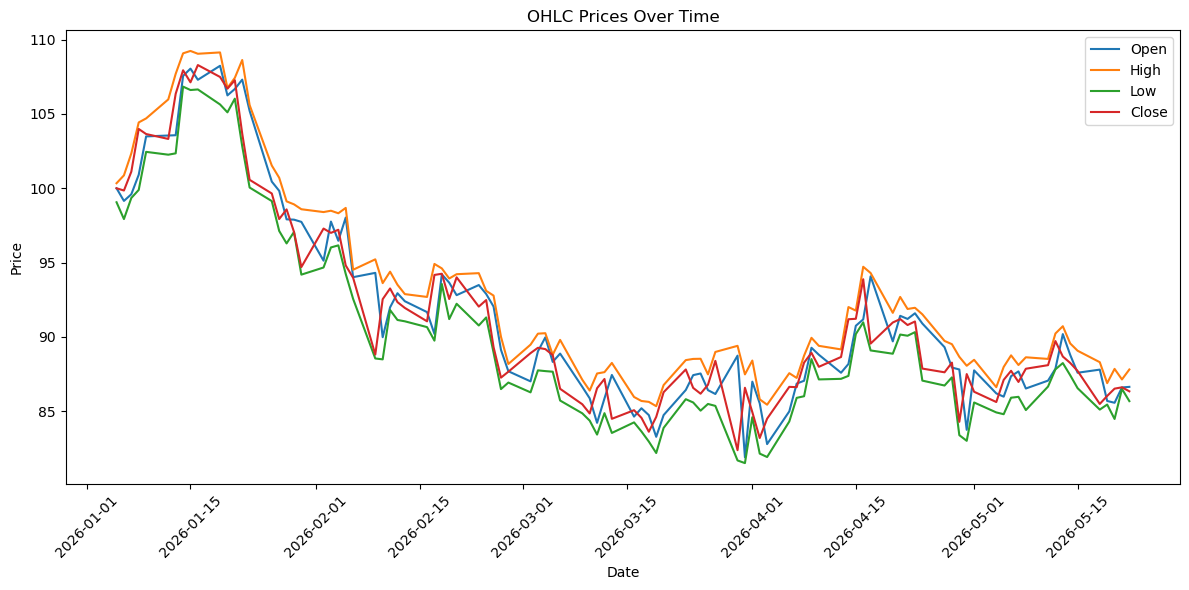

In [2]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Close"], label="Close")

plt.title("OHLC Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

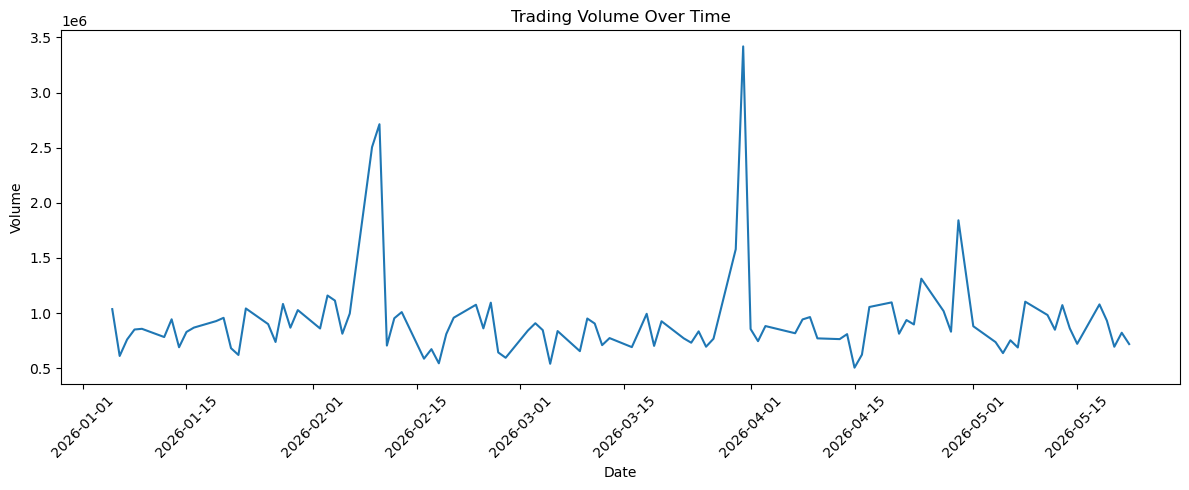

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Volume"])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

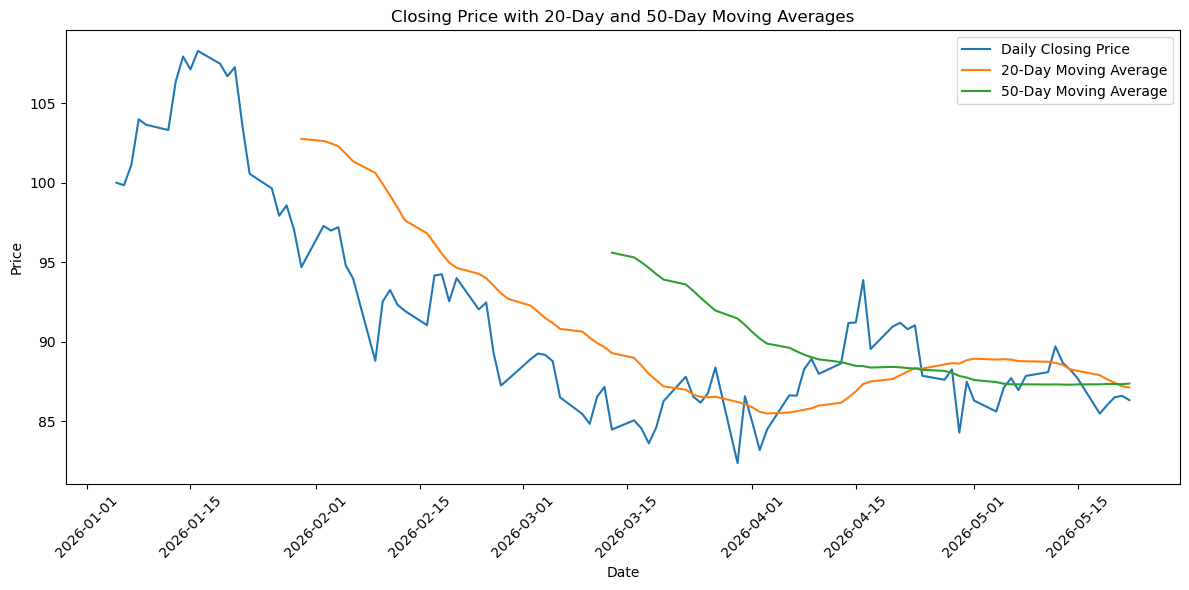

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Close"], label="Daily Closing Price")
plt.plot(df["Date"], df["MA_20"], label="20-Day Moving Average")
plt.plot(df["Date"], df["MA_50"], label="50-Day Moving Average")

plt.title("Closing Price with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

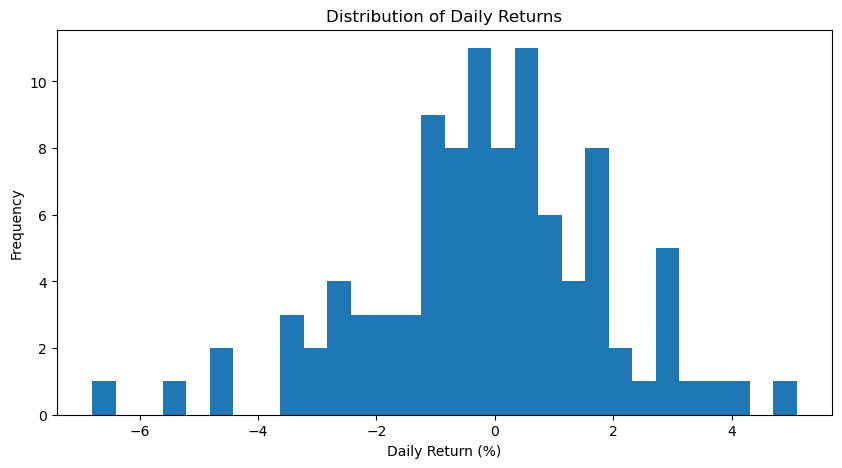

In [5]:
plt.figure(figsize=(10, 5))

plt.hist(df["Daily_Return"], bins=30)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

In [6]:
mean_return = df["Daily_Return"].mean()
variance_return = df["Daily_Return"].var()
std_return = df["Daily_Return"].std()

max_return = df["Daily_Return"].max()
min_return = df["Daily_Return"].min()

print("FINANCIAL SUMMARY")
print("-------------------------")
print("Average Daily Return:", mean_return)
print("Variance:", variance_return)
print("Standard Deviation:", std_return)
print("Maximum Daily Return:", max_return)
print("Minimum Daily Return:", min_return)

FINANCIAL SUMMARY
-------------------------
Average Daily Return: -0.1276724688587717
Variance: 4.128054554727939
Standard Deviation: 2.031761441392158
Maximum Daily Return: 5.0983248361252675
Minimum Daily Return: -6.799411698155911


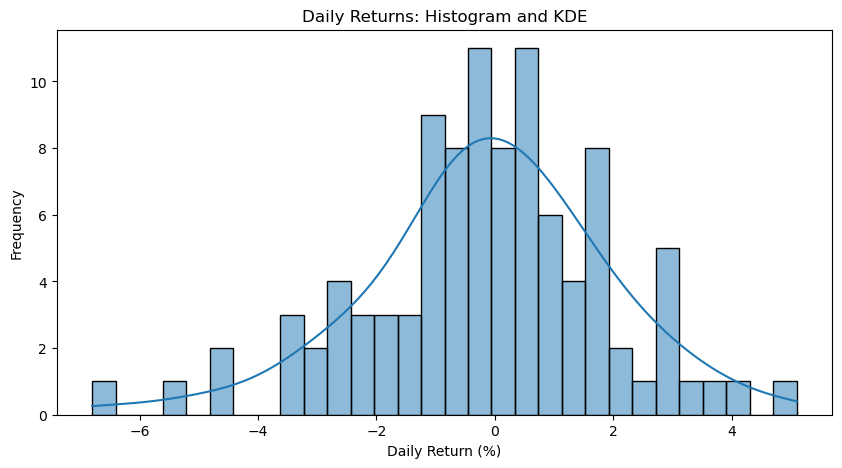

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=30,
     
)

plt.title("Daily Returns: Histogram and KDE")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()